In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded=files.upload()

Saving heart.csv to heart.csv


In [3]:
df=pd.read_csv("/content/heart.csv")

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [6]:
df.shape

(1025, 14)

In [7]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [11]:
df.duplicated().sum()

np.int64(723)

In [12]:
df = df.drop_duplicates()

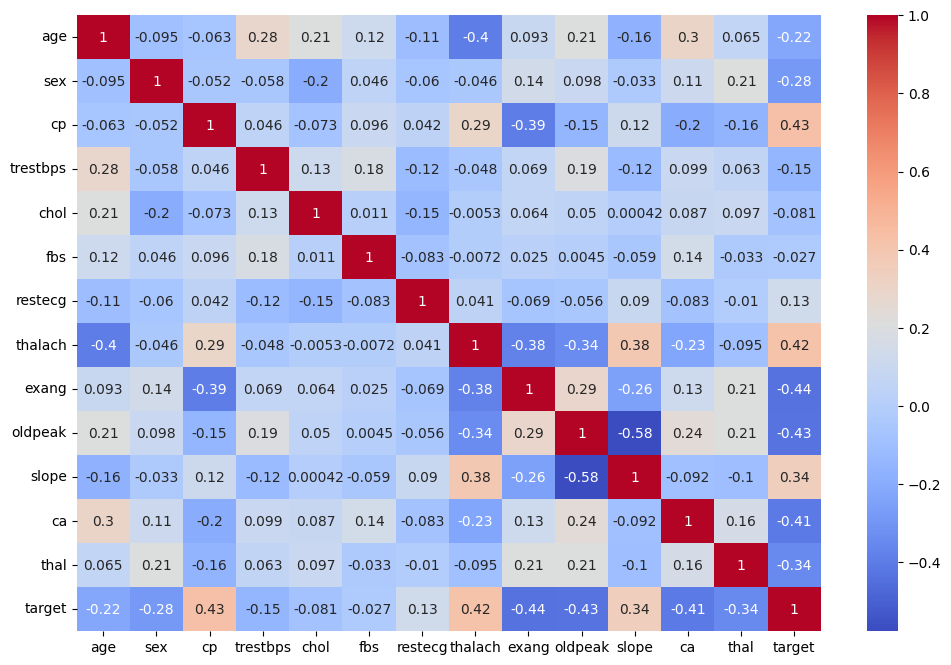

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

plt.show()

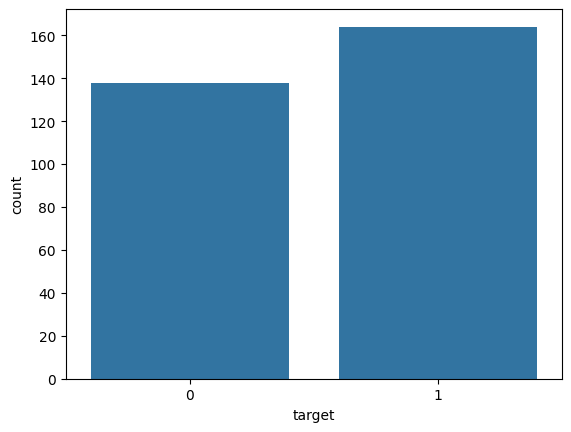

In [14]:
sns.countplot(x='target',data=df)

plt.show()

In [15]:
X = df.drop("target",axis=1)

y = df["target"]

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
from sklearn.tree import DecisionTreeClassifier

cart = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

cart.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [20]:
cart_pred = cart.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

cart_accuracy = accuracy_score(
    y_test,
    cart_pred
)

print("CART Accuracy:",cart_accuracy)

CART Accuracy: 0.7377049180327869


In [22]:
id3 = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

id3.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [23]:
id3_pred=id3.predict(X_test)

In [24]:
print("ID3 Accuracy:",
accuracy_score(y_test,id3_pred))

ID3 Accuracy: 0.7213114754098361


In [25]:
c45 = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

c45.fit(X_train,y_train)

c45_pred=c45.predict(X_test)

print("C4.5 Approximate Accuracy:",
accuracy_score(y_test,c45_pred))

C4.5 Approximate Accuracy: 0.7213114754098361


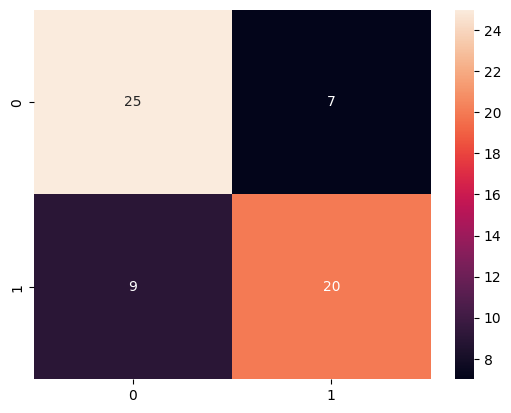

In [26]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,cart_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.show()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    cart_pred
))

              precision    recall  f1-score   support

           0       0.74      0.78      0.76        32
           1       0.74      0.69      0.71        29

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



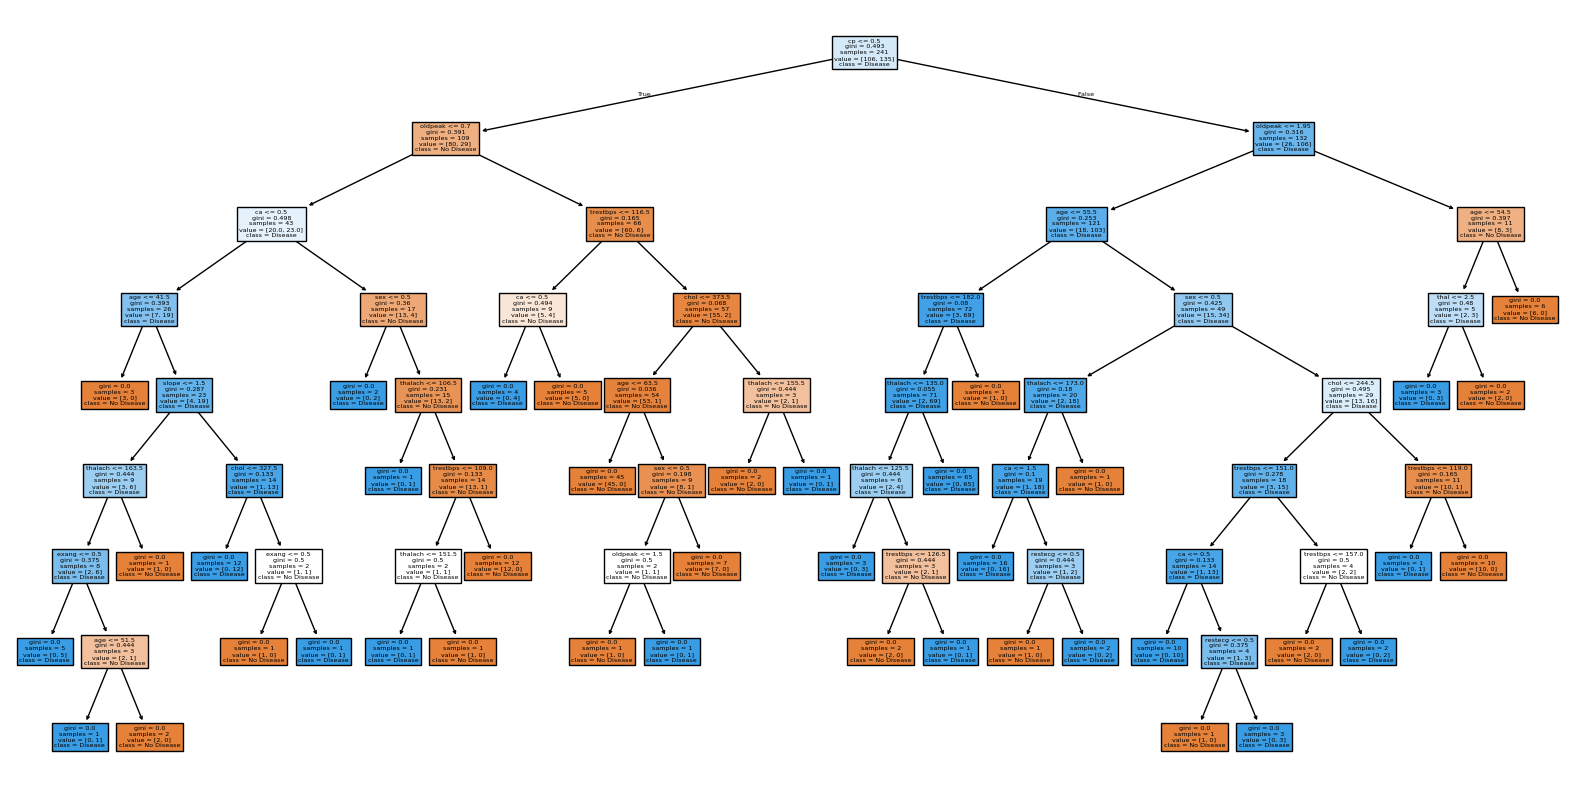

In [28]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    cart,
    feature_names=X.columns,
    class_names=['No Disease','Disease'],
    filled=True
)

plt.show()

In [29]:
sample=[[52,1,2,172,199,1,1,162,0,0.5,2,0,2]]

prediction=cart.predict(sample)

print(prediction)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
